# 8.2 - The Effect of Transformations on Analysis

In this notebook, we examine how different transformations change the distribution of data and how this affects analysis.

The goal is not simply to obtain "nicer" distributions, but to make the data easier to understand, easier to visualize, and more suitable for certain methods.

Throughout the notebook, we compare the original and transformed variables and examine how the following change:
- the shapes of the distributions,
- descriptive statistics,
- the effect of outliers,
- and the relationships between variables.

The aim is to understand that transformation is not a purely technical step, but an important tool in data analysis.

## A Brief Introduction to the Diamonds Dataset

The `Diamonds` dataset contains the characteristics and prices of different diamonds.  
Each row represents one diamond, while the columns describe its main properties, such as:

- `carat`: the weight of the diamond,
- `cut`: the quality of the cut,
- `color`: the color grade,
- `clarity`: the clarity,
- `depth`, 	`table`: proportion-related characteristics,
- `x`, `y`, `z`: the dimensions of the diamond,
- `price`: the price.

This dataset is especially useful for exploratory data analysis because:
- it contains both **numerical** and **categorical** variables,
- it is well suited for studying **distributions**,
- it allows us to search for **outliers**,
- we can analyze **relationships** between variables,
- and it is a good example for showing which factors may be related to **price**.

In [21]:
# Import the libraries used in this notebook
import pandas as pd
import json
import urllib.request

# Create a direct download link from the shared Google Drive link
csv_file_id = "1VITxcqN4GcmSwEtguRXABQNesTmibD74"

csv_url = f"https://drive.google.com/uc?export=download&id={csv_file_id}"

# Load the intentionally "messy" Diamonds CSV file
# Each row represents one diamond, but the dataset intentionally contains errors,
# so we can practice the steps of EDA and data cleaning
df = pd.read_csv(csv_url)

# Display the first 5 rows of the data
# This helps us quickly understand what one observation looks like
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Selecting the Numerical Variables to Study

Since in this notebook we want to examine the effect of transformations, we will focus primarily on the numerical variables.

As a first step, we select the numerical columns and then inspect some of their important characteristics.  
We pay special attention to which variables may have skewed distributions, because for those the effect of transformations can be especially interesting.

In [22]:
# Select the numeric columns
numeric_cols = df.select_dtypes(include="number").columns

numeric_cols

Index(['carat', 'depth', 'table', 'price', 'x', 'y', 'z'], dtype='object')

## Quick Statistical Overview

The basic statistical indicators of the numerical variables help us form a first impression of the dataset.

Based on the mean, median, minimum, maximum, and standard deviation, we can already suspect that for some variables:
- the spread may be large,
- outliers may occur,
- or the distribution may be asymmetric.

Next, we will also examine skewness separately.

In [23]:
# Let's look at the summary statistics for numerical variables
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
carat,54160.0,0.799187,0.482073,0.0,0.40,0.70,1.04,7.07
depth,54080.0,61.748878,1.451045,41.7,61.00,61.80,62.50,81.70
table,54080.0,57.460749,2.253750,43.0,56.00,57.00,59.00,95.00
price,54160.0,3954.149354,4119.279447,60.0,949.00,2401.00,5335.00,110367.00
x,54039.0,5.735474,1.171601,0.0,4.71,5.70,6.54,24.42
y,54060.0,5.739400,1.191251,0.0,4.72,5.71,6.54,58.90
z,54059.0,3.542591,0.746257,0.0,2.91,3.53,4.04,31.80


## Uniform Preparation of the Numerical Variables

Since later we want to study the relationships among several numerical variables, it is better not to clean just one column separately, but to prepare all relevant numerical variables at the same time.

During this process we:

- select the numerical columns,
- mark obviously incorrect, non-positive values,
- remove incomplete or invalid rows,
- and then use IQR-based filtering to reduce the effect of extreme outliers.

This gives us a uniformly cleaned dataset that will make relationship analysis and transformations easier later on.

In [24]:
# Select the numeric columns
numeric_cols = df.select_dtypes(include="number").columns.tolist()

numeric_cols

['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

## Marking Invalid, Non-Positive Values

For some numerical variables, values of 0 or negative values are not meaningful.  
This is true, for example, for variables describing size, weight, or price.

We now mark these uniformly with the value -1, so that in the next step we can remove them easily.

It is important to note that we only apply this to variables where strictly positive values are genuinely expected.

In [25]:
# Let's copy only the numeric columns
df_num = df[numeric_cols].copy()


In [26]:
# Columns where only positive values are allowed
positive_required_cols = ["carat", "price", "x", "y", "z"]

# Non-positive values are denoted by -1
for col in positive_required_cols:
    if col in df_num.columns:
        df_num.loc[df_num[col] <= 0, col] = -1

In [27]:
# Let's see how many incorrectly marked values there are in each column
for col in positive_required_cols:
    if col in df_num.columns:
        print(f"{col} = -1:", (df_num[col] == -1).sum())

carat = -1: 10
price = -1: 0
x = -1: 33
y = -1: 28
z = -1: 40


## Removing Invalid and Missing Rows

In the next step, we remove rows where one of the selected positive variables is missing or invalid.

This ensures that later relationship analyses and the Box-Cox transformation are performed on appropriate input data.

In [28]:
# First, remove the missing values from the relevant columns
df_num_clean = df_num.dropna(subset=positive_required_cols).copy()

# Next, remove the rows where any of the relevant columns has a value of -1
for col in positive_required_cols:
    df_num_clean = df_num_clean[df_num_clean[col] > 0]

df_num_clean.shape

(53743, 7)

## IQR-Based Filtering for Numerical Variables

We now apply IQR-based filtering to the selected positive numerical variables.

The goal here is not to treat every outlier as an error, but to reduce the impact of extreme observations so that relationship analysis and correlation become easier to interpret.

In [29]:
# Let's create a copy for IQR filtering
df_num_iqr = df_num_clean.copy()

# We will retain, row by row, those observations
# that fall within the IQR limits in every column examined
mask = pd.Series(True, index=df_num_iqr.index)

for col in positive_required_cols:
    q1 = df_num_iqr[col].quantile(0.25)
    q3 = df_num_iqr[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = mask & df_num_iqr[col].between(lower, upper)

df_num_iqr = df_num_iqr[mask].copy()

print("After cleaning:", df_num_clean.shape)
print("After IQR filtering:", df_num_iqr.shape)

After cleaning: (53743, 7)
After IQR filtering: (49944, 7)


## The Prepared Numerical Dataset

At this point, we have a numerical data frame in which:

- invalid non-positive values have been removed,
- missing values have been filtered out in the relevant columns,
- and the impact of extreme outliers has also been reduced.

From here, we can use this data frame as the basis for scatterplots, regplots, correlation analysis, or Box-Cox transformations.

## Examining the Relationship on the Original Scale

As a first step, we use a scatterplot to examine how carat and price are related in the original data.

A scatterplot helps us observe:

- whether there is a relationship between the two variables,
- how scattered the points are,
- and how strongly the larger values stretch the scale.

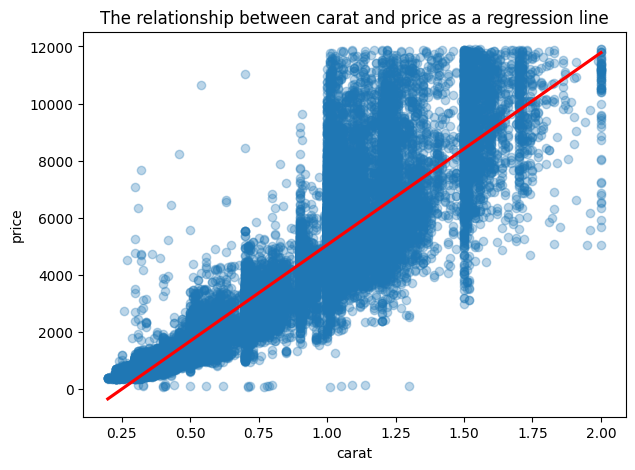

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7, 5))
sns.regplot(data=df_num_iqr, x="carat", y="price", scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})
plt.title("The relationship between carat and price as a regression line")
plt.xlabel("carat")
plt.ylabel("price")
plt.show()

In [31]:
# Pearson correlation between the original variables
df_num_iqr[["carat", "price"]].corr()

,carat,price
carat,1.00000,0.91756
price,0.91756,1.00000


## What Do We See on the Original Scale?

Based on the plots, we can see that there is a relationship between `carat` and `price`, but on the original scale the larger values can still strongly stretch the point cloud even after preprocessing.

This can make it harder:

- to interpret the shape of the relationship visually,
- to examine the lower and middle value ranges,
- and it may not be the most favorable input for some models either.

That is why we now transform the same variables using Box-Cox.

## Applying the Box-Cox Transformation

We now apply the Box-Cox transformation to both `carat` and `price`.

The goal is to place the same information on a scale where the structure of the relationship is easier to see.

In [32]:
from scipy.stats import boxcox

# Box-Cox transformation for both variables
df_num_iqr["carat_boxcox"], lambda_carat = boxcox(df_num_iqr["carat"])
df_num_iqr["price_boxcox"], lambda_price = boxcox(df_num_iqr["price"])

print("carat lambda:", round(lambda_carat, 3))
print("price lambda:", round(lambda_price, 3))

carat lambda: -0.009
price lambda: -0.017


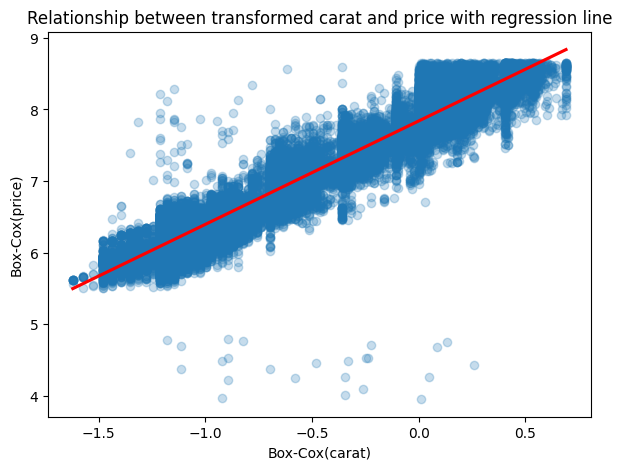

In [33]:
plt.figure(figsize=(7, 5))
sns.regplot(
    data=df_num_iqr,
    x="carat_boxcox",
    y="price_boxcox",
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "red"}
)
plt.title("Relationship between transformed carat and price with regression line")
plt.xlabel("Box-Cox(carat)")
plt.ylabel("Box-Cox(price)")
plt.show()

In [34]:
# Pearson correlation between the transformed variables
df_num_iqr[["carat_boxcox", "price_boxcox"]].corr()

,carat_boxcox,price_boxcox
carat_boxcox,1.000000,0.957619
price_boxcox,0.957619,1.000000


## What Did We Gain from the Transformation?

After the transformation, the structure of the relationship is usually easier to see.

The larger values no longer stretch the scale as much, so:

- the point cloud becomes easier to interpret,
- the differences among the smaller and medium values are more visible,
- and the form of the relationship becomes easier to understand.

So the transformation does not create a new relationship; it shows the same relationship on a scale where it is easier to examine.

## Exercises

In the previous example, we already saw how the appearance of a relationship can change between the original and transformed data.

Now examine the following variable pairs on your own:

- `x` vs `price`
- `y` vs `price`
- `z` vs `price`





## Exercise 1 - x and price

Examine the relationship between `x` and `price` in the prepared data.

### Task:
1. Create a new data frame that contains only the `x` and `price` columns.
2. Create a regplot for the original variables as well.
3. Compute the Pearson correlation on the original data.
4. Apply the Box-Cox transformation to both variables.
5. Create a regplot for the transformed variables as well.
6. Compute the Pearson correlation between the transformed variables.
7. Compare the original and transformed relationships.

### Think about:
- How clearly could the relationship be seen on the original scale?
- Did Box-Cox help make the point cloud easier to interpret?
- Did the correlation value change?

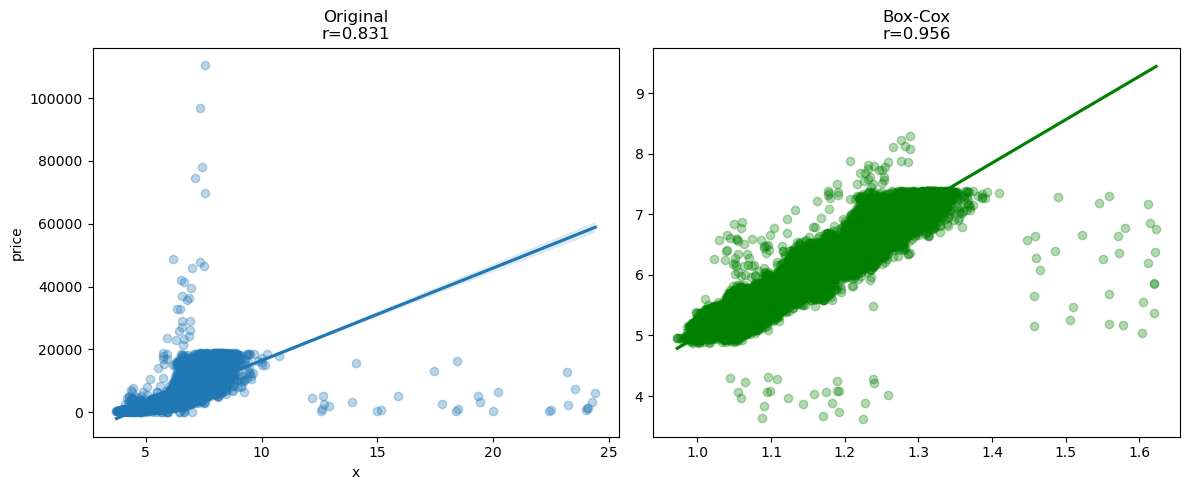

Original correlation: 0.8309266162953192
Box-Cox correlation: 0.9560132600129227
Lambda x: -0.48570597993388426
Lambda price: -0.061504466445391204


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import boxcox, pearsonr

# Import the libraries used in this notebook
import pandas as pd
import json
import urllib.request

# Create a direct download link from the shared Google Drive link
csv_file_id = "1VITxcqN4GcmSwEtguRXABQNesTmibD74"

csv_url = f"https://drive.google.com/uc?export=download&id={csv_file_id}"

# Load the intentionally "messy" Diamonds CSV file
# Each row represents one diamond, but the dataset intentionally contains errors,
# so we can practice the steps of EDA and data cleaning
df = pd.read_csv(csv_url)

# Select data
data = df[["x", "price"]].dropna()
data = data[(data["x"] > 0) & (data["price"] > 0)]

# Correlation (original)
corr_orig, _ = pearsonr(data["x"], data["price"])

# Box-Cox transform
x_bc, lam_x = boxcox(data["x"])
price_bc, lam_p = boxcox(data["price"])

# Correlation (Box-Cox)
corr_bc, _ = pearsonr(x_bc, price_bc)

# Plot original
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.regplot(x=data["x"], y=data["price"], scatter_kws={"alpha": 0.3})
plt.title(f"Original\nr={corr_orig:.3f}")

# Plot transformed
plt.subplot(1, 2, 2)
sns.regplot(x=x_bc, y=price_bc, scatter_kws={"alpha": 0.3}, color="green")
plt.title(f"Box-Cox\nr={corr_bc:.3f}")

plt.tight_layout()
plt.show()

# Print results
print("Original correlation:", corr_orig)
print("Box-Cox correlation:", corr_bc)
print("Lambda x:", lam_x)
print("Lambda price:", lam_p)

## Exercise 2 - `y` and `price`

Examine the relationship between `y` and `price` in the prepared data.

### Task:
1. Create a new data frame that contains only the `y` and `price` columns.
2. Create a regplot for the original variables as well.
3. Compute the Pearson correlation on the original data.
4. Apply the Box-Cox transformation to both variables.
5. Create a regplot for the transformed variables as well.
6. Compute the Pearson correlation between the transformed variables.
7. Compare the original and transformed relationships.

### Think about:
- How clearly could the relationship be seen on the original scale?
- Did Box-Cox help make the point cloud easier to interpret?
- Did the correlation value change?

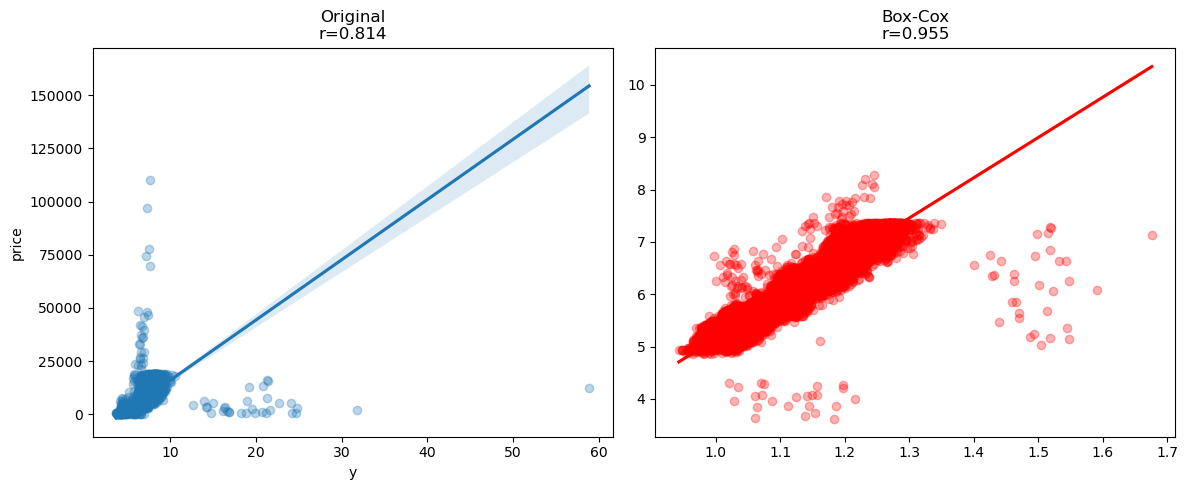

Original correlation: 0.8136001124726577
Box-Cox correlation: 0.9552187738360087
Lambda y: -0.5271164424976433
Lambda price: -0.06215656103496825


In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import boxcox, pearsonr

# Import the libraries used in this notebook
import pandas as pd
import json
import urllib.request

# Create a direct download link from the shared Google Drive link
csv_file_id = "1VITxcqN4GcmSwEtguRXABQNesTmibD74"

csv_url = f"https://drive.google.com/uc?export=download&id={csv_file_id}"

# Load the intentionally "messy" Diamonds CSV file
# Each row represents one diamond, but the dataset intentionally contains errors,
# so we can practice the steps of EDA and data cleaning
df = pd.read_csv(csv_url)

# Select data
data = df[["y", "price"]].dropna()
data = data[(data["y"] > 0) & (data["price"] > 0)]

# Correlation (original)
corr_orig, _ = pearsonr(data["y"], data["price"])

# Box-Cox transform
y_bc, lam_y = boxcox(data["y"])
price_bc, lam_p = boxcox(data["price"])

# Correlation (Box-Cox)
corr_bc, _ = pearsonr(y_bc, price_bc)

# Plot original
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.regplot(x=data["y"], y=data["price"], scatter_kws={"alpha": 0.3})
plt.title(f"Original\nr={corr_orig:.3f}")

# Plot transformed
plt.subplot(1, 2, 2)
sns.regplot(x=y_bc, y=price_bc, scatter_kws={"alpha": 0.3}, color="red")
plt.title(f"Box-Cox\nr={corr_bc:.3f}")

plt.tight_layout()
plt.show()

# Print results
print("Original correlation:", corr_orig)
print("Box-Cox correlation:", corr_bc)
print("Lambda y:", lam_y)
print("Lambda price:", lam_p)

## Exercise 3 - `carat` and `price`

Examine the relationship between `carat` and `price` in the prepared data.

### Task:
1. Create a new data frame that contains only the`carat` and `price` columns.
2. Create a regplot for the original variables as well.
3. Compute the Pearson correlation on the original data.
4. Apply the Box-Cox transformation to both variables.
5. Create a regplot for the transformed variables as well.
6. Compute the Pearson correlation between the transformed variables.
7. Compare the original and transformed relationships.

### Think about:
- How clearly could the relationship be seen on the original scale?
- Did Box-Cox help make the point cloud easier to interpret?
- Did the correlation value change?

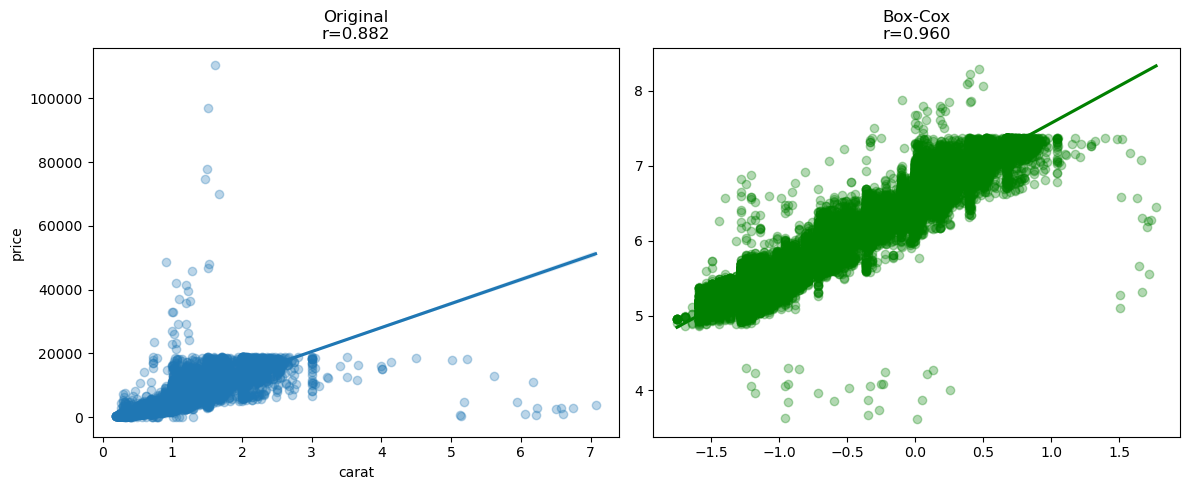

Original correlation: 0.8819460122354305
Box-Cox correlation: 0.9603651547595724
Lambda carat: -0.10387160122154307
Lambda price: -0.061726427107890364


In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import boxcox, pearsonr

# Import the libraries used in this notebook
import pandas as pd
import json
import urllib.request

# Create a direct download link from the shared Google Drive link
csv_file_id = "1VITxcqN4GcmSwEtguRXABQNesTmibD74"

csv_url = f"https://drive.google.com/uc?export=download&id={csv_file_id}"

# Load the intentionally "messy" Diamonds CSV file
# Each row represents one diamond, but the dataset intentionally contains errors,
# so we can practice the steps of EDA and data cleaning
df = pd.read_csv(csv_url)

# Select data
data = df[["carat", "price"]].dropna()
data = data[(data["carat"] > 0) & (data["price"] > 0)]

# Correlation (original)
corr_orig, _ = pearsonr(data["carat"], data["price"])

# Box-Cox transform
carat_bc, lam_c = boxcox(data["carat"])
price_bc, lam_p = boxcox(data["price"])

# Correlation (Box-Cox)
corr_bc, _ = pearsonr(carat_bc, price_bc)

# Plot original
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.regplot(x=data["carat"], y=data["price"], scatter_kws={"alpha": 0.3})
plt.title(f"Original\nr={corr_orig:.3f}")

# Plot transformed
plt.subplot(1, 2, 2)
sns.regplot(x=carat_bc, y=price_bc, scatter_kws={"alpha": 0.3}, color="green")
plt.title(f"Box-Cox\nr={corr_bc:.3f}")

plt.tight_layout()
plt.show()

# Print results
print("Original correlation:", corr_orig)
print("Box-Cox correlation:", corr_bc)
print("Lambda carat:", lam_c)
print("Lambda price:", lam_p)